#  Heart Disease Prediction using Logistic Regression

Author: Varun Singh

## Objective

Build a Machine Learning classification model to predict whether a person is likely to have heart disease based on medical attributes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load Dataset

In [2]:
df = pd.read_csv("/content/heart-disease.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Check Dataset Size

In [3]:
df.shape

(303, 14)

## Check Column Names

In [4]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

## Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


## Statistical Summary

In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Check Missing Values

In [7]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


## Visualize Target Distribution

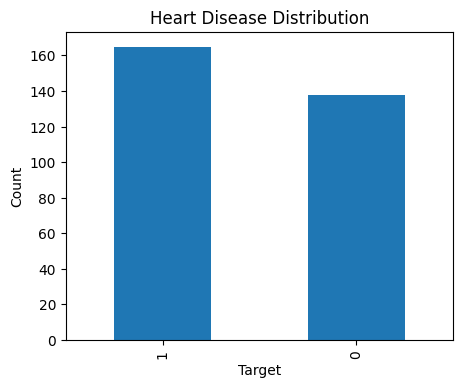

In [8]:
plt.figure(figsize=(5,4))

df["target"].value_counts().plot(kind="bar")

plt.title("Heart Disease Distribution")

plt.xlabel("Target")

plt.ylabel("Count")

plt.show()

## Correlation Heatmap

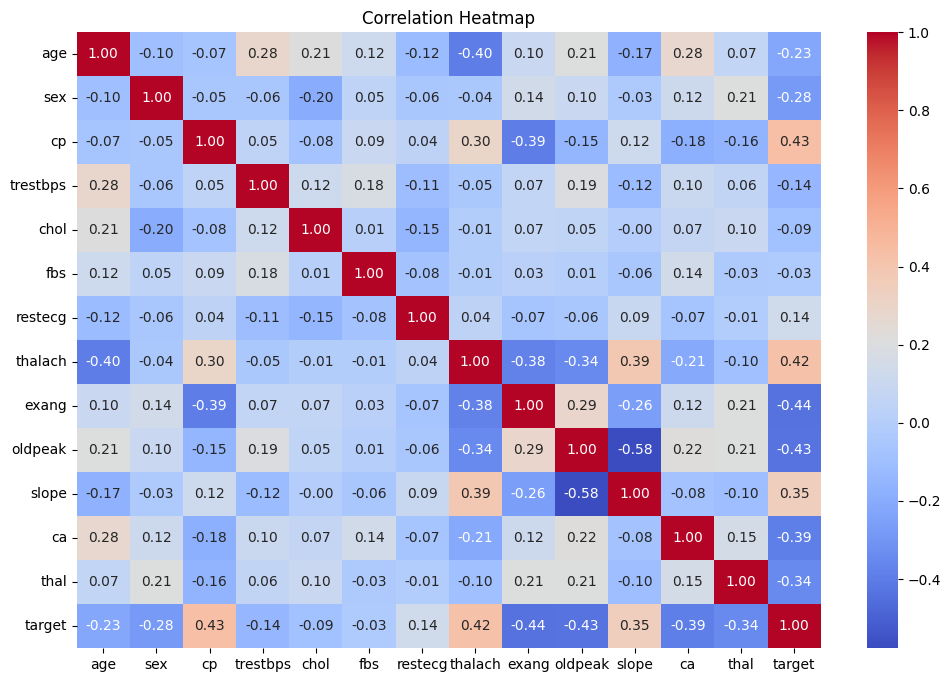

In [9]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

## Features (X) aur Target (y)

In [10]:
X = df.drop("target", axis=1)

y = df["target"]

## Check Features

In [11]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


## Check Target

In [12]:
y.head()

,target
0,1
1,1
2,1
3,1
4,1


## Train-Test Split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Check Dataset Shape

In [14]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (242, 13)
Testing Data: (61, 13)


## Feature Scaling

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

## Import Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression

## Create Model

In [17]:
model = LogisticRegression(random_state=42)

## Train Model

In [18]:
model.fit(X_train, y_train)

LogisticRegression(random_state=42)

## Predict

In [19]:
y_pred = model.predict(X_test)

print(y_pred)

[0 1 1 0 1 1 1 0 0 0 1 0 1 0 1 1 1 0 0 0 1 0 0 1 1 1 1 1 0 1 0 0 0 0 1 0 1
 1 1 1 0 1 1 1 1 0 1 1 0 0 0 0 1 1 0 0 0 1 0 0 0]


## Compare Actual vs Predicted

In [20]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
179,0,0
228,0,1
111,1,1
246,0,0
60,1,1
9,1,1
119,1,1
223,0,0
268,0,0
33,1,0


## Import Evaluation Metrics

In [21]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

## Accuracy Score

In [22]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.8524590163934426


## Confusion Matrix

In [23]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[25  4]
 [ 5 27]]


## Confusion Matrix Visualization

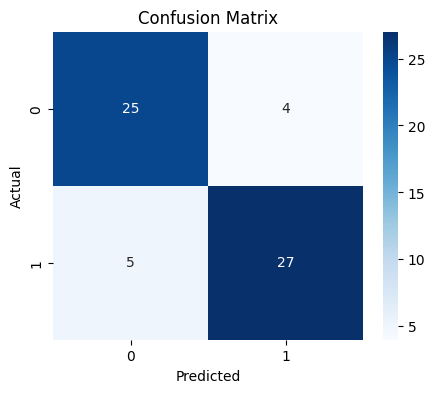

In [24]:
import seaborn as sns

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Classification Report

In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



## ROC-AUC Score

In [26]:
roc = roc_auc_score(y_test, y_pred)

print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.8529094827586207


## Predict for a New Patient

In [27]:
new_patient = [[52, 1, 2, 130, 230, 0, 1, 150, 0, 1.2, 2, 0, 2]]

new_patient = scaler.transform(new_patient)

prediction = model.predict(new_patient)

if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")

Heart Disease Detected


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Model Coefficients

In [28]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients

,Feature,Coefficient
0,age,-0.085591
1,sex,-0.783086
2,cp,0.817904
3,trestbps,-0.273307
4,chol,-0.174841
5,fbs,0.090312
6,restecg,0.284179
7,thalach,0.395131
8,exang,-0.517584
9,oldpeak,-0.681396


# ✅ Key Learnings

- Loaded the Heart Disease dataset
- Explored and analyzed the dataset
- Visualized target distribution
- Visualized feature correlation
- Split the dataset into training and testing sets
- Applied feature scaling
- Trained a Logistic Regression model
- Predicted heart disease outcomes
- Evaluated the model using Accuracy, Confusion Matrix, Classification Report, and ROC-AUC Score